In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import optical_cond as oc
import my_my_maxent as maxent
import importlib

import scienceplots
plt.style.use(['science','no-latex'])
from IPython.display import set_matplotlib_formats
set_matplotlib_formats("svg") 

plt.rcParams['lines.markersize'] = 1
plt.rcParams['lines.linewidth'] = 1

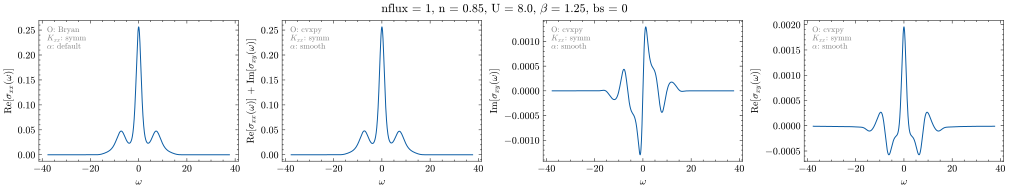

In [18]:
pickle_folder = '/scratch/users/rebjin/kohler_pickles/8x8_tp0_morebins/nflux1/n0.85/'
sig = get_sig_pickle(pickle_folder, 8, 1.25)
oc.plot_results(sig)


# pickle_folder = f'/scratch/users/rebjin/kohler_pickles/8x8_tp0/nflux{nflux}/n{n}/'
# sig = get_sig_pickle(pickle_folder, U, beta)


False about to plot


/home/users/rebjin/.local/lib/python3.9/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


True about to plot
Als failed to solve: 0/121


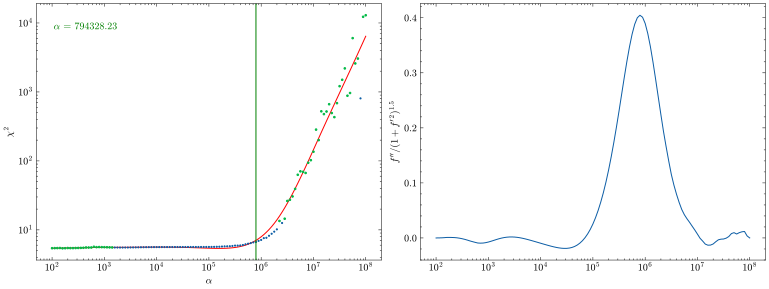

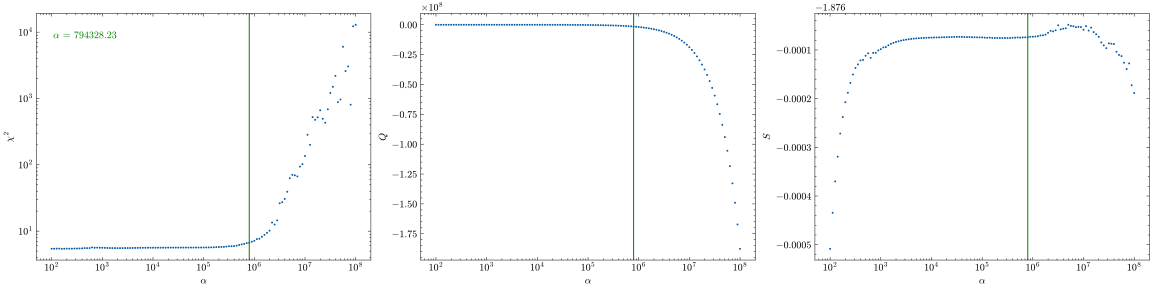

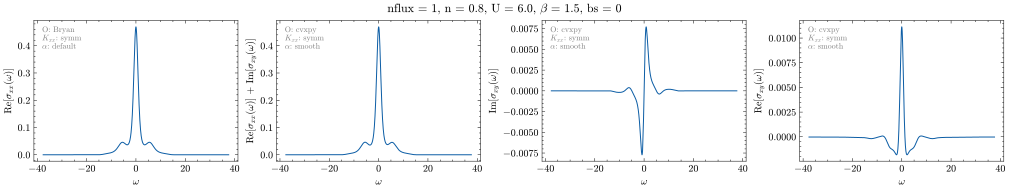

In [13]:
num_w = 400
ws, dws = maxent.gen_grid(num_w, -2.1, 2.1, lambda x: 0.4 * np.sinh(2.5 * x))

settings_xx = {
    'mdl': 'flat',
    'krnl': 'symm',
    'opt_method': 'Bryan',
    'inspect_al': True,
    'smooth_al': False
}
settings_xy = {
    'mdl': 'flat',
    'opt_method': 'cvxpy',
    'inspect_al': True,
    'smooth_al': True   # whether to use smoothed alpha selection (necessary for constr. opt_method == 'cvxpy')
}

# path = '/scratch/users/rebjin/8x8_tp0_morebins/nflux1/n0.85/beta1.25_U8_mu-2.392/'
path = '/scratch/users/rebjin/8x8_tp0_morebins/nflux1/n0.8/beta1.5_U6_mu-1.988/'
# path = '/oak/stanford/orgs/simes/jxding/jxding-desktop-Data-DQMC/8x8_tp0/nflux1/n0.85/beta1.25_U8_mu-2.392/'
sig = oc.sigma(path, 'xy', ws, dws, settings_xx=settings_xx, settings_xy = settings_xy, bs=0)
oc.plot_results(sig)



False about to plot


/home/users/rebjin/.local/lib/python3.9/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


True about to plot
Als failed to solve: 0/121


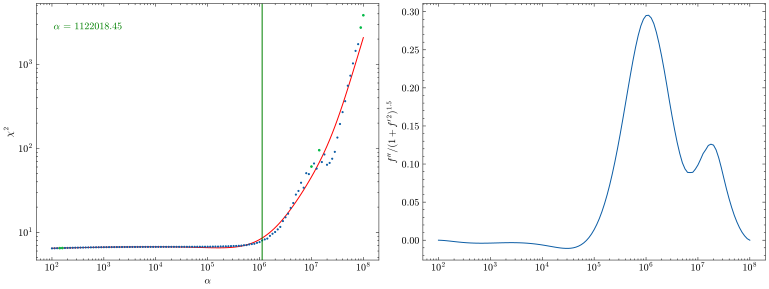

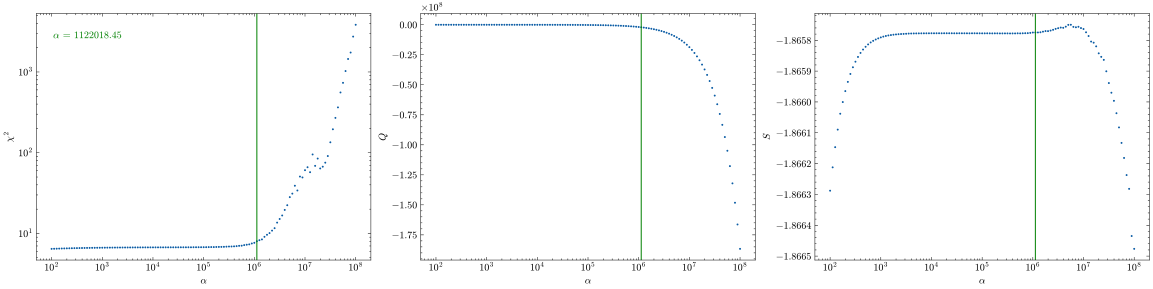

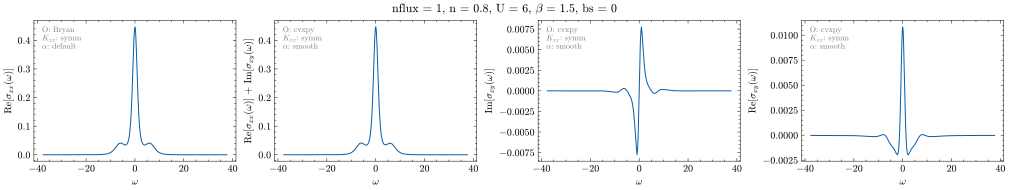

In [14]:
num_w = 400
ws, dws = maxent.gen_grid(num_w, -2.1, 2.1, lambda x: 0.4 * np.sinh(2.5 * x))

settings_xx = {
    'mdl': 'flat',
    'krnl': 'symm',
    'opt_method': 'Bryan',
    'inspect_al': True,
    'smooth_al': False
}
settings_xy = {
    'mdl': 'flat',
    'opt_method': 'cvxpy',
    'inspect_al': True,
    'smooth_al': True   # whether to use smoothed alpha selection (necessary for constr. opt_method == 'cvxpy')
}

# path = '/scratch/users/rebjin/8x8_tp0/nflux1/n0.85/beta1.25_U8_mu-2.392/'
# path = '/scratch/users/rebjin/8x8_tp0/nflux1/n0.85/beta1.25_U8_mu-2.392/'
path = '/oak/stanford/orgs/simes/jxding/jxding-desktop-Data-DQMC/8x8_tp0/nflux1/n0.8/beta1.5_U6_mu-1.988/'
sig = oc.sigma(path, 'xy', ws, dws, settings_xx=settings_xx, settings_xy = settings_xy, bs=0)
oc.plot_results(sig)



In [21]:
import re
import ast

def convert_type(value):
    # Check for boolean values
    if value.lower() in {"true", "false"}:
        return value.lower() == "true"

    # Try to convert to integer
    try:
        return int(value)
    except ValueError:
        pass

    # Try to convert to float
    try:
        return float(value)
    except ValueError:
        pass

    # Default to string
    return value

pattern = '(\w+)=(\S+)'
line = 'hello what is going on --out_folder=whatever --U=2 --beta=1.25 --path=sdfljs/sdflkjsdlfk/sdlfkj '

matches = re.findall(pattern, line)
params = dict(matches)
print(params)

params = {k: convert_type(v) for k, v in params.items()}
print(params) 
# print(ast.literal_eval('whatever'))

{'out_folder': 'whatever', 'U': '2', 'beta': '1.25', 'path': 'sdfljs/sdflkjsdlfk/sdlfkj'}
{'out_folder': 'whatever', 'U': 2, 'beta': 1.25, 'path': 'sdfljs/sdflkjsdlfk/sdlfkj'}


In [24]:
a = 'hello'

a += 'bello'
print(a)

hellobello


In [17]:
def get_sig_pickle(folder_name, U, beta):
    # folder_name directs to pickle output folder with U, beta files in it (specify nflux and n in path)
    pickle_path = None
    for file in os.listdir(folder_name):
        if (f'U{U}_' in file) and (f'beta{beta:g}_' in file):
            # print(folder_name+file)
            pickle_path = folder_name + file
            break
    
    # If matching pickle file not found in folder_name
    if not pickle_path:
        raise FileNotFoundError(f"No file found for U={U} and beta={beta} in {folder_name}")
        
    # Load sig
    with open(pickle_path, 'rb') as file:
        sig = pickle.load(file)
    return sig

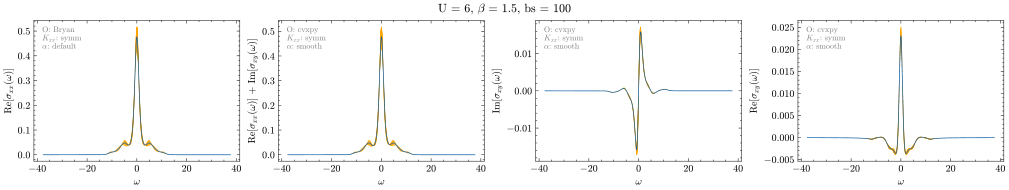

{'mdl': 'flat', 'krnl': 'symm', 'opt_method': 'Bryan', 'inspect_al': False, 'smooth_al': False}
{'mdl': 'flat', 'opt_method': 'cvxpy', 'inspect_al': False, 'smooth_al': True}
/oak/stanford/orgs/simes/jxding/jxding-desktop-Data-DQMC/8x8_tp0/nflux2/n0.8/beta1.5_U6_mu-1.987/


/home/users/rebjin/.local/lib/python3.9/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Als failed to solve: 0/121


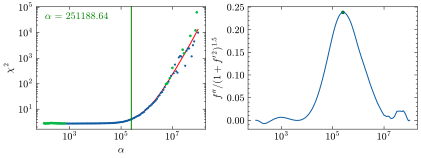

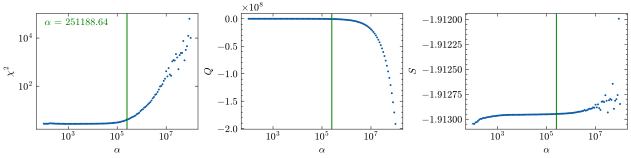

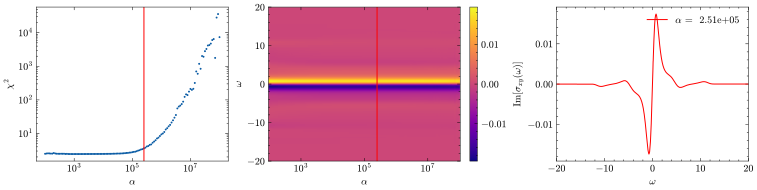

In [132]:
# Look at this because it looks so bizarre
importlib.reload(maxent)
importlib.reload(optical_cond)

U = 6
beta = 1.5
n = 0.8
nflux = 2
# print(rho_df[(rho_df['U'] == U) & (rho_df['beta'] == beta) & (rho_df['n'] == n)])

pickle_folder = f'/scratch/users/rebjin/kohler_pickles/8x8_tp0/nflux{nflux}/n{n}/'
sig = get_sig_pickle(pickle_folder, U, beta)

optical_cond.plot_results(sig, bs_mode='errorbar')
print(sig.settings_xx)
print(sig.settings_xy)

print(optical_cond.find_data_folder('/oak/stanford/orgs/simes/jxding/jxding-desktop-Data-DQMC/8x8_tp0/', nflux, n, U, beta))
optical_cond.inspect_al(sig, 'xy', 45, als_plot=[], redo_select_al=True)

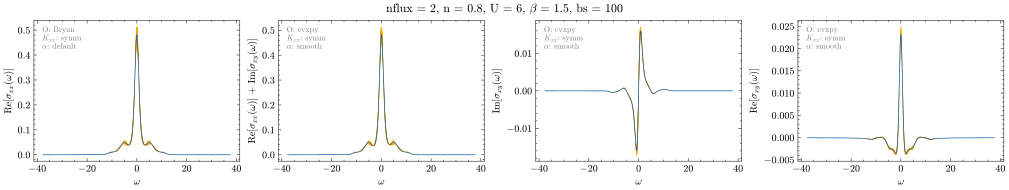

{'mdl': 'flat', 'krnl': 'symm', 'opt_method': 'Bryan', 'inspect_al': False, 'smooth_al': False}
{'mdl': 'flat', 'opt_method': 'cvxpy', 'inspect_al': False, 'smooth_al': True}
/oak/stanford/orgs/simes/jxding/jxding-desktop-Data-DQMC/8x8_tp0/nflux2/n0.8/beta1.5_U6_mu-1.987/


/home/users/rebjin/.local/lib/python3.9/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Als failed to solve: 0/121


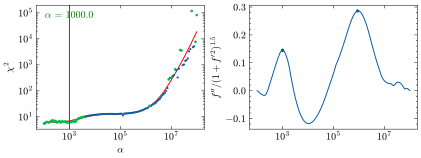

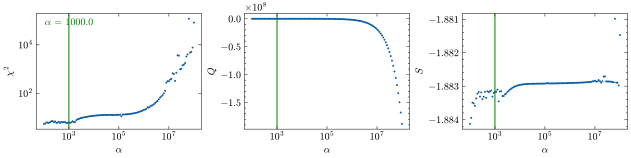

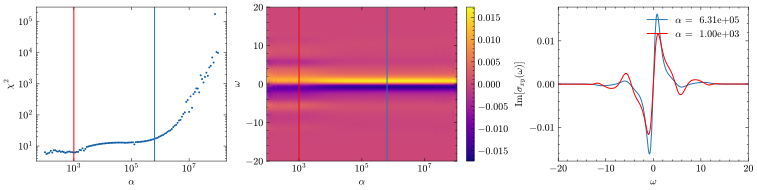

In [131]:
# Look at this because it looks so bizarre
importlib.reload(maxent)
importlib.reload(optical_cond)

U = 6
beta = 1.5
n = 0.8
nflux = 2
# print(rho_df[(rho_df['U'] == U) & (rho_df['beta'] == beta) & (rho_df['n'] == n)])

pickle_folder = f'/scratch/users/rebjin/kohler_pickles/8x8_tp0_test/nflux{nflux}/n{n}/'
sig = get_sig_pickle(pickle_folder, U, beta)

optical_cond.plot_results(sig, bs_mode='errorbar')
print(sig.settings_xx)
print(sig.settings_xy)

print(optical_cond.find_data_folder('/oak/stanford/orgs/simes/jxding/jxding-desktop-Data-DQMC/8x8_tp0/', nflux, n, U, beta))
optical_cond.inspect_al(sig, 'xy', 46, als_plot=[10**5.8], redo_select_al=True)

In [118]:
optical_cond.get_bs_outliers(sig, mode='xx')
optical_cond.get_bs_outliers(sig, mode='xy')
# print(np.array(sig.results['al_xx']))
# print(sig.results)

[19 79 43 65 51 77 12  7 73 78 72 95  4 26 75 10 49 22  5  8 24 21 59 23
 57 67 90 31 60 45 32 86 68  0 83 40 53 55 81 84 97 87 15 82 50 41 44 66
 48 30 33 58  6 89 64 70 52 35 98 25 71 96 92  9 76 13 17 74 42 38 37 62
 69 16 94 56 20  1 11 28 61 80 88 47 39 99 93 34 18 46 91 54  2 27 29  3
 63 85 14 36]
[46 19 79 43 51  4 73 10 24 21 65 23 12 77 95  7 78 72 22 26 49  5  8 75
 59 31 90 57 67 68 32 83 45 86 60  0 40 97 81 53 15 48 55 33 84 87 44 66
 41 50 30  6 58 82 71 76 64 96 92 99 98 13 89 17 35 42 52  9 25 70 39 69
 62 37 74 16 11  1 29 38 61 94 18 20 63 34 56 88 28 47 93 80 85 54 91  2
 36 27  3 14]


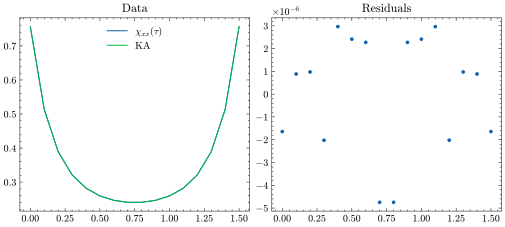

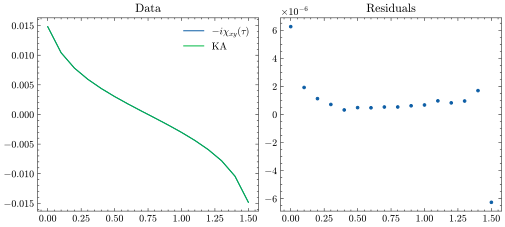

In [121]:
importlib.reload(optical_cond)
optical_cond.check_KA(sig, mode='xx', bs=None)
optical_cond.check_KA(sig, mode='xy', bs=None)

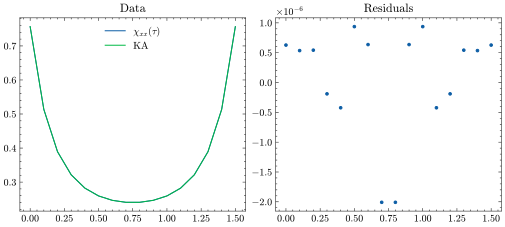

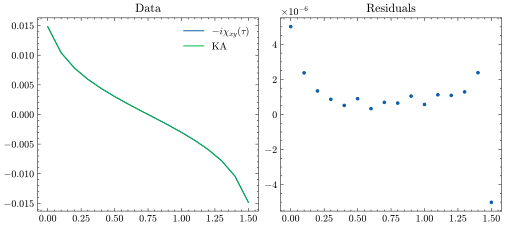

In [15]:
importlib.reload(optical_cond)

optical_cond.check_KA(sig, mode='xx', bs=83)
optical_cond.check_KA(sig, mode='xy', bs=83)

In [96]:
### Test new data lol
importlib.reload(maxent)
importlib.reload(optical_cond)

num_w = 400
ws, dws = maxent.gen_grid(num_w, -2.1, 2.1, lambda x: 0.4 * np.sinh(2.5 * x))

settings_xx = {
    'mdl': 'flat',
    'krnl': 'symm',
    'opt_method': 'Bryan',
    'inspect_al': True,
    'smooth_al': False
}
settings_xy = {
    'mdl': 'flat',
    'opt_method': 'cvxpy',
    'inspect_al': True,
    'smooth_al': True   # whether to use smoothed alpha selection (necessary for constr. opt_method == 'cvxpy')
}

path = '/scratch/users/rebjin/8x8_tp0/nflux2/n0.8/beta1.5_U6_mu-1.987/'
sig_test = optical_cond.sigma(path, 'xy', ws, dws, settings_xx=settings_xx, settings_xy = settings_xy, bs=bs)

Sigma_xy bootstraps:   0%|          | 0/50 [00:00<?, ?it/s]

False about to plot


/home/users/rebjin/.local/lib/python3.9/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
Sigma_xy bootstraps:   2%|▏         | 1/50 [00:04<03:18,  4.04s/it]

False about to plot
False about to plot


Sigma_xy bootstraps:   4%|▍         | 2/50 [00:08<03:12,  4.00s/it]

False about to plot
False about to plot


Sigma_xy bootstraps:   6%|▌         | 3/50 [00:12<03:14,  4.13s/it]

False about to plot
False about to plot


Sigma_xy bootstraps:   6%|▌         | 3/50 [00:12<03:20,  4.27s/it]


KeyboardInterrupt: 

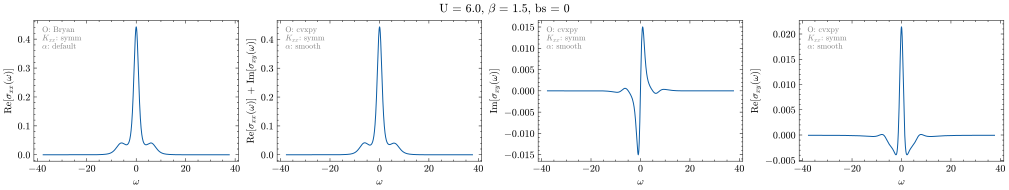

In [95]:
optical_cond.plot_results(sig_test)